# Financial Risk Classification

This notebook builds a logistic regression classifier to identify customers at financial risk based on their expense and savings behaviour.

**Input:** `cleaned_expenses.csv` (32 columns, 20,000 rows)  
**Target:** Binary `risk_label` — 1 if a customer spends heavily and saves little, 0 otherwise

**Sections:**
1. Imports
2. Load data
3. Feature engineering — define `expense_ratio` and `risk_label`
4. Baseline logistic regression (unscaled)
5. Scaled pipeline — fix convergence and compare coefficients
6. Visualise predicted probabilities
7. Refined model — drop low-importance feature and evaluate

## 1. Imports

In [1]:
from pathlib import Path
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 2. Load Data

In [2]:
data_path = Path(os.getcwd()).parent
raw_df = pd.read_csv(f"{data_path}/data/cleaned_expenses.csv")
df = raw_df.copy()
df.head()

,Cust_ID,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,...,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous,total_expenses,total_potential_savings,actual_savings,savings_rate
0,7069,108385.38,47,4,Student,Tier_2,21677.08,0.0,4941.36,16115.86,...,1061.40,277.63,1568.40,148.46,226.49,179.07,74136.06,6413.79,34249.32,0.32
1,3940,16169.75,55,0,Self_Employed,Tier_3,2425.46,0.0,344.87,1906.18,...,99.48,41.89,68.21,6.44,0.00,23.19,8315.71,755.39,7854.04,0.49
2,19775,62931.79,34,0,Self_Employed,Tier_2,12586.36,0.0,2671.17,7919.59,...,329.29,250.59,308.69,100.11,0.00,53.71,38719.54,2325.91,24212.25,0.38
3,13691,144887.62,60,0,Self_Employed,Tier_2,28977.52,0.0,5960.67,19429.45,...,896.24,380.49,588.51,88.56,0.00,319.05,90647.21,4524.15,54240.41,0.37
4,1194,38745.82,56,0,Retired,Tier_1,11623.75,0.0,1193.15,4605.88,...,184.43,198.55,773.35,13.67,0.00,81.70,26767.21,1889.75,11978.61,0.31


## 3. Feature Engineering

Two new columns are created:

- **`expense_ratio`** — total expenses as a proportion of income. A ratio above 0.75 indicates high spending relative to earnings.
- **`risk_label`** — binary target. A customer is labelled high-risk (1) if their `expense_ratio > 0.75` **and** `savings_rate < 0.2`. All other customers are labelled low-risk (0).

In [3]:
df["expense_ratio"] = df["total_expenses"] / df["Income"]
df["risk_label"] = np.where(
    (df["expense_ratio"] > 0.75) & (df["savings_rate"] < 0.2),
    1,  # High risk
    0   # Low risk
)

df.head()

,Cust_ID,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,...,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous,total_expenses,total_potential_savings,actual_savings,savings_rate,expense_ratio,risk_label
0,7069,108385.38,47,4,Student,Tier_2,21677.08,0.0,4941.36,16115.86,...,1568.40,148.46,226.49,179.07,74136.06,6413.79,34249.32,0.32,0.684004,0
1,3940,16169.75,55,0,Self_Employed,Tier_3,2425.46,0.0,344.87,1906.18,...,68.21,6.44,0.00,23.19,8315.71,755.39,7854.04,0.49,0.514276,0
2,19775,62931.79,34,0,Self_Employed,Tier_2,12586.36,0.0,2671.17,7919.59,...,308.69,100.11,0.00,53.71,38719.54,2325.91,24212.25,0.38,0.615262,0
3,13691,144887.62,60,0,Self_Employed,Tier_2,28977.52,0.0,5960.67,19429.45,...,588.51,88.56,0.00,319.05,90647.21,4524.15,54240.41,0.37,0.625638,0
4,1194,38745.82,56,0,Retired,Tier_1,11623.75,0.0,1193.15,4605.88,...,773.35,13.67,0.00,81.70,26767.21,1889.75,11978.61,0.31,0.690841,0


## 4. Baseline Logistic Regression

### 4a. Define features and target

Four features are used: `Income`, `expense_ratio`, `savings_rate`, and `Age`. These cover absolute wealth, relative spending, saving behaviour, and demographic context.

In [4]:
X = df[["Income", "expense_ratio", "savings_rate", "Age"]]
y = df["risk_label"]

### 4b. Train / test split and fit

An 80/20 train-test split is used with `random_state=42` for reproducibility.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

C:\Users\hardb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 4c. Evaluate

The baseline model achieves 99.5% accuracy. Precision and recall are both high for both classes, suggesting the risk threshold is well-separated in feature space.

In [6]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.995
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2930
           1       1.00      0.98      0.99      1070

    accuracy                           0.99      4000
   macro avg       1.00      0.99      0.99      4000
weighted avg       1.00      0.99      0.99      4000



### 4d. Predicted probabilities

`predict_proba` returns a (n_samples, 2) array. Column 0 is P(low risk) and column 1 is P(high risk). Inspecting the first five rows gives a sense of how confident the model is in its predictions.

In [7]:
risk_prob = model.predict_proba(X_test)

risk_prob[:5]

array([[6.26174932e-01, 3.73825068e-01],
       [9.04386517e-01, 9.56134827e-02],
       [9.92372724e-01, 7.62727578e-03],
       [9.79303805e-01, 2.06961954e-02],
       [9.99997638e-01, 2.36233326e-06]])

### 4e. Coefficients (unscaled)

Because the features are not standardised, the raw coefficients cannot be compared directly. `Income` has a tiny coefficient (~-0.000002) not because it is unimportant, but because a one-unit change in income (i.e. $1) is negligible. `savings_rate` and `expense_ratio` dominate due to their small natural scale.

In [8]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coeff_df

,Feature,Coefficient
0,Income,-0.000002
1,expense_ratio,19.479334
2,savings_rate,-29.608441
3,Age,0.005394


## 5. Scaled Pipeline

Wrapping `StandardScaler` and `LogisticRegression` in a `Pipeline` ensures that:
1. Scaling is fit only on training data and applied consistently to test data — preventing data leakage.
2. The solver converges reliably because all features are on a comparable scale.

In [9]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipe.fit(X_train, y_train)
y_pred_2 = pipe.predict(X_test)
risk_prob_2 = pipe.predict_proba(X_test)

Standardised coefficients confirm that `expense_ratio` (positive) and `savings_rate` (negative) drive the prediction. A high expense ratio increases risk probability; a high savings rate decreases it

In [10]:
coeff_df_2 = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": pipe.named_steps['model'].coef_[0]
})

coeff_df_2

,Feature,Coefficient
0,Income,0.005394
1,expense_ratio,13.196303
2,savings_rate,-14.153140
3,Age,-0.019463


## 6. Predicted Probability vs Key Features

The scatter plots illustrate how predicted risk probability relates to the two strongest predictors. The near-perfect separation visible in both plots explains the high model accuracy — the rule-based label used in section 3 creates a very clean boundary.

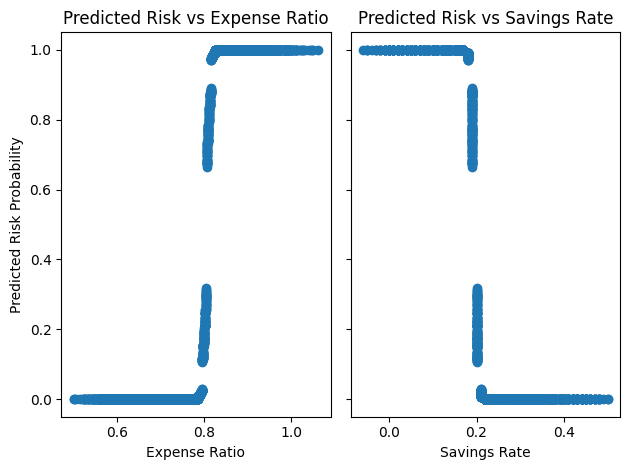

In [11]:
fig, (ax1,ax2) = plt.subplots(1,2, sharey=True)
ax1.scatter(X_test['expense_ratio'], risk_prob_2[:,1])
ax1.set_xlabel('Expense Ratio')
ax1.set_ylabel('Predicted Risk Probability')
ax1.set_title('Predicted Risk vs Expense Ratio')

ax2.scatter(X_test['savings_rate'], risk_prob_2[:,1])
ax2.set_xlabel('Savings Rate')
ax2.set_title('Predicted Risk vs Savings Rate')

plt.tight_layout()
plt.show()

## 7. Refined Model — Drop `Income`

Given that `Income` had near-zero standardised coefficient, the model is retrained without it. The expectation is that accuracy stays the same or improves slightly, and the model becomes more interpretable with fewer inputs.

In [12]:
X = X.drop("Income",axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model2 = LogisticRegression()
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)

Accuracy improves marginally from 99.5% to 99.6% after removing `Income`, confirming it was not a useful predictor. The classification report shows improved recall for the high-risk class (1).

In [13]:
accuracy2 = accuracy_score(y_test, y_pred)
print(f"Accuracy after dropping income: {accuracy2} compared to earlier {accuracy}")

print(classification_report(y_test, y_pred))

Accuracy after dropping income: 0.99625 compared to earlier 0.995
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2930
           1       1.00      0.99      0.99      1070

    accuracy                           1.00      4000
   macro avg       1.00      0.99      1.00      4000
weighted avg       1.00      1.00      1.00      4000



### Confusion Matrix

The confusion matrix quantifies the error breakdown.

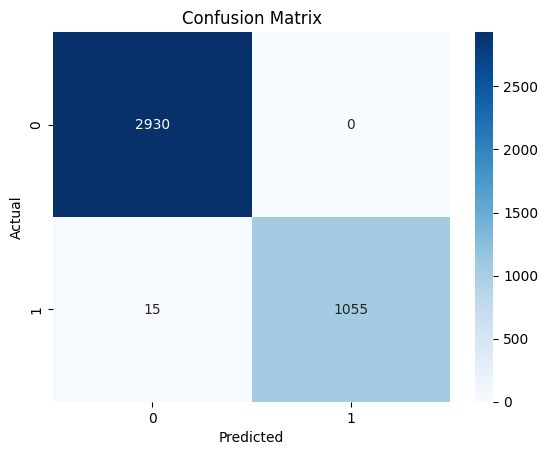

In [14]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()